# 4. Stabla odlučivanja

## Osnovna ideja

Proces donošenja odluka može se modelovati nizom **if–then–else** pravila koja grananjem
vode do klasifikacije.

Stabla odlučivanja su direktno povezana sa **ekspertskim sistemima**:

| | ekspertski sistem | stablo odlučivanja |
|---|---|---|
| oblik znanja | if–then pravila | if–then pravila |
| kako nastaju | **ručno ih piše ekspert** | **uče se automatski iz podataka** |

Primer pravila:

```
IF Balance > 2000
    IF Income < 40k  ->  Kredit = ODBIJEN
    ELSE             ->  Kredit = ODOBREN
ELSE                 ->  Kredit = ODBIJEN
```

## Struktura stabla

| element | uloga |
|---|---|
| **čvor** | proverava atribut (kolonu) |
| **grana** | vrednost atributa (najčešće binarna) |
| **list** | konačna odluka / klasa |

Ključni izazov nije ideja stabla, nego **kako naučiti stablo iz podataka** — konkretno,
**kako izabrati atribut za grananje**.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.datasets import load_iris, load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score

plt.rcParams["figure.figsize"] = (9, 4.5); plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True; plt.rcParams["grid.alpha"] = 0.3
RS = 42
print("Spremno.")

Spremno.


## Entropija

Da bismo automatski izabrali najbolji atribut, uvodimo meru **neuređenosti** podataka —
**entropiju**.

Neka je $S$ skup trening instanci, $S^+$ pozitivni i $S^-$ negativni primeri:

$$p_+ = \frac{|S^+|}{|S|}, \qquad p_- = \frac{|S^-|}{|S|}$$

$$H(S) = -p_+ \log_2 p_+ - p_- \log_2 p_-$$

| entropija | značenje |
|---|---|
| **niska (0)** | skup je čist — sve instance su iste klase |
| **visoka (1)** | klase su savršeno pomešane |

### Zašto baš entropija — veza sa teorijom informacija

Poruka sa verovatnoćom $P$ zahteva dužinu koda $-\log_2 P$. Česta poruka dobija kratak
kod, retka dug. Entropija je **prosečan broj bitova** potrebnih za kodiranje poruke,
odnosno mera **neizvesnosti**.

Oznaka $H$ potiče od Claude-a Shannon-a.

   sve pozitivno                H = 0.0000
   9 poz / 1 neg                H = 0.4690
   pola-pola                    H = 1.0000
   9 poz / 5 neg (Play Tennis)  H = 0.9403


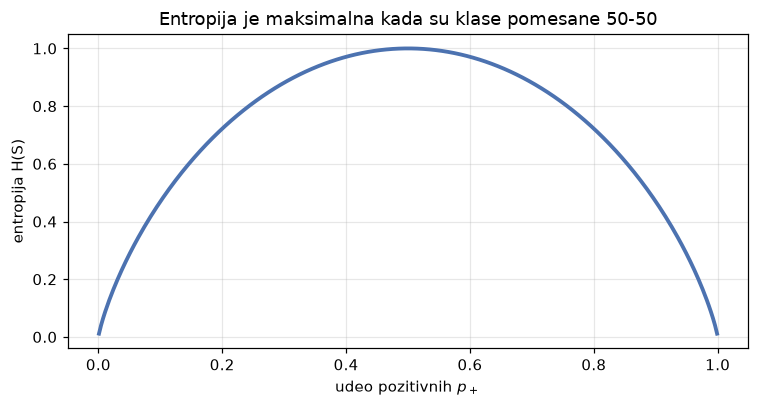

In [2]:
def entropija(p_plus):
    'Entropija binarnog skupa sa udelom pozitivnih p_plus.'
    if p_plus in (0, 1):
        return 0.0
    p_minus = 1 - p_plus
    return -p_plus * np.log2(p_plus) - p_minus * np.log2(p_minus)

for opis, poz, neg in [("sve pozitivno", 10, 0), ("9 poz / 1 neg", 9, 1),
                       ("pola-pola", 5, 5), ("9 poz / 5 neg (Play Tennis)", 9, 5)]:
    p = poz / (poz + neg)
    print(f"   {opis:<28} H = {entropija(p):.4f}")

pp = np.linspace(0.001, 0.999, 300)
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(pp, [entropija(x) for x in pp], lw=2.5, color="#4C72B0")
ax.set_xlabel("udeo pozitivnih $p_+$"); ax.set_ylabel("entropija H(S)")
ax.set_title("Entropija je maksimalna kada su klase pomesane 50-50")
plt.tight_layout(); plt.show()

## Information Gain (dobitak informacije)

Meri **koliko se smanjuje neizvesnost** kada podelimo podatke po nekom atributu:

$$IG(S, A) = H(S) - \sum_{i} \frac{|S_i|}{|S|} H(S_i)$$

gde su $S_i$ podskupovi nastali grananjem po atributu $A$.

- **veći IG** → bolji atribut
- bira se atribut sa **najvećim** IG i on postaje korenski čvor

### Primer — Play Tennis

Klasičan primer sa predavanja. Skup ima **9 „Yes"** i **5 „No"**, pa je $H(S) \approx 0.94$.

Pitanje: koji atribut staviti u koren — `Outlook` ili `Temperature`?

In [3]:
tenis = pd.DataFrame({
    "Day":     [f"D{i}" for i in range(1, 15)],
    "Outlook": ["Sunny","Sunny","Overcast","Rain","Rain","Rain","Overcast",
                "Sunny","Sunny","Rain","Sunny","Overcast","Overcast","Rain"],
    "Temp":    ["Hot","Hot","Hot","Mild","Cool","Cool","Cool",
                "Mild","Cold","Mild","Mild","Mild","Hot","Mild"],
    "PlayTennis": ["No","No","Yes","Yes","Yes","No","Yes",
                   "No","Yes","Yes","Yes","Yes","Yes","No"],
})
display(tenis)

def H(oznake):
    n = len(oznake)
    if n == 0: return 0.0
    return -sum((c/n) * np.log2(c/n) for c in pd.Series(oznake).value_counts() if c > 0)

Hs = H(tenis.PlayTennis)
print(f"\nH(S) = {Hs:.4f}   ({(tenis.PlayTennis=='Yes').sum()} Yes, {(tenis.PlayTennis=='No').sum()} No)")

,Day,Outlook,Temp,PlayTennis
0,D1,Sunny,Hot,No
1,D2,Sunny,Hot,No
2,D3,Overcast,Hot,Yes
3,D4,Rain,Mild,Yes
4,D5,Rain,Cool,Yes
5,D6,Rain,Cool,No
6,D7,Overcast,Cool,Yes
7,D8,Sunny,Mild,No
8,D9,Sunny,Cold,Yes
9,D10,Rain,Mild,Yes



H(S) = 0.9403   (9 Yes, 5 No)


In [4]:
def information_gain(df, atribut, cilj="PlayTennis"):
    'IG(S,A) = H(S) - suma (|Si|/|S|) * H(Si)'
    ukupno = H(df[cilj])
    posle = 0.0
    print(f"\nAtribut '{atribut}':")
    for vrednost, grupa in df.groupby(atribut):
        udeo = len(grupa) / len(df)
        h = H(grupa[cilj])
        posle += udeo * h
        poz = (grupa[cilj] == "Yes").sum(); neg = (grupa[cilj] == "No").sum()
        print(f"   {vrednost:<10} S=[{poz}+, {neg}-]  |S_i|/|S| = {len(grupa)}/{len(df)}  H = {h:.4f}")
    ig = ukupno - posle
    print(f"   -> IG = {ukupno:.4f} - {posle:.4f} = {ig:.4f}")
    return ig

ig_out = information_gain(tenis, "Outlook")
ig_tmp = information_gain(tenis, "Temp")

print(f"\n{'='*54}")
print(f"IG(Outlook)     = {ig_out:.4f}")
print(f"IG(Temperature) = {ig_tmp:.4f}")
print(f"-> Outlook ide u koren: znatno vise smanjuje entropiju.")


Atribut 'Outlook':
   Overcast   S=[4+, 0-]  |S_i|/|S| = 4/14  H = -0.0000
   Rain       S=[3+, 2-]  |S_i|/|S| = 5/14  H = 0.9710
   Sunny      S=[2+, 3-]  |S_i|/|S| = 5/14  H = 0.9710
   -> IG = 0.9403 - 0.6935 = 0.2467

Atribut 'Temp':
   Cold       S=[1+, 0-]  |S_i|/|S| = 1/14  H = -0.0000
   Cool       S=[2+, 1-]  |S_i|/|S| = 3/14  H = 0.9183
   Hot        S=[2+, 2-]  |S_i|/|S| = 4/14  H = 1.0000
   Mild       S=[4+, 2-]  |S_i|/|S| = 6/14  H = 0.9183
   -> IG = 0.9403 - 0.8760 = 0.0642

IG(Outlook)     = 0.2467
IG(Temperature) = 0.0642
-> Outlook ide u koren: znatno vise smanjuje entropiju.


## Algoritam ID3

1. Počni sa celim skupom podataka
2. Izračunaj entropiju
3. Za svaki atribut izračunaj Information Gain
4. Izaberi atribut sa **najvećim** dobitkom
5. Podeli podatke po tom atributu
6. Ponovi postupak **rekurzivno** na svakom podskupu

## Algoritmi za konstrukciju stabla

| algoritam | autor / godina | osobine |
|---|---|---|
| **ID3** | Quinlan, 1984–85 | prvi; entropija + information gain; samo diskretni atributi |
| **C4.5 / C5.0** | Quinlan | poboljšani ID3; podržavaju **kontinuirane** atribute |
| **CART** | — | koristi se u `scikit-learn`; Gini indeks ili entropija |

Tacnost: trening 0.9810, test 0.9333



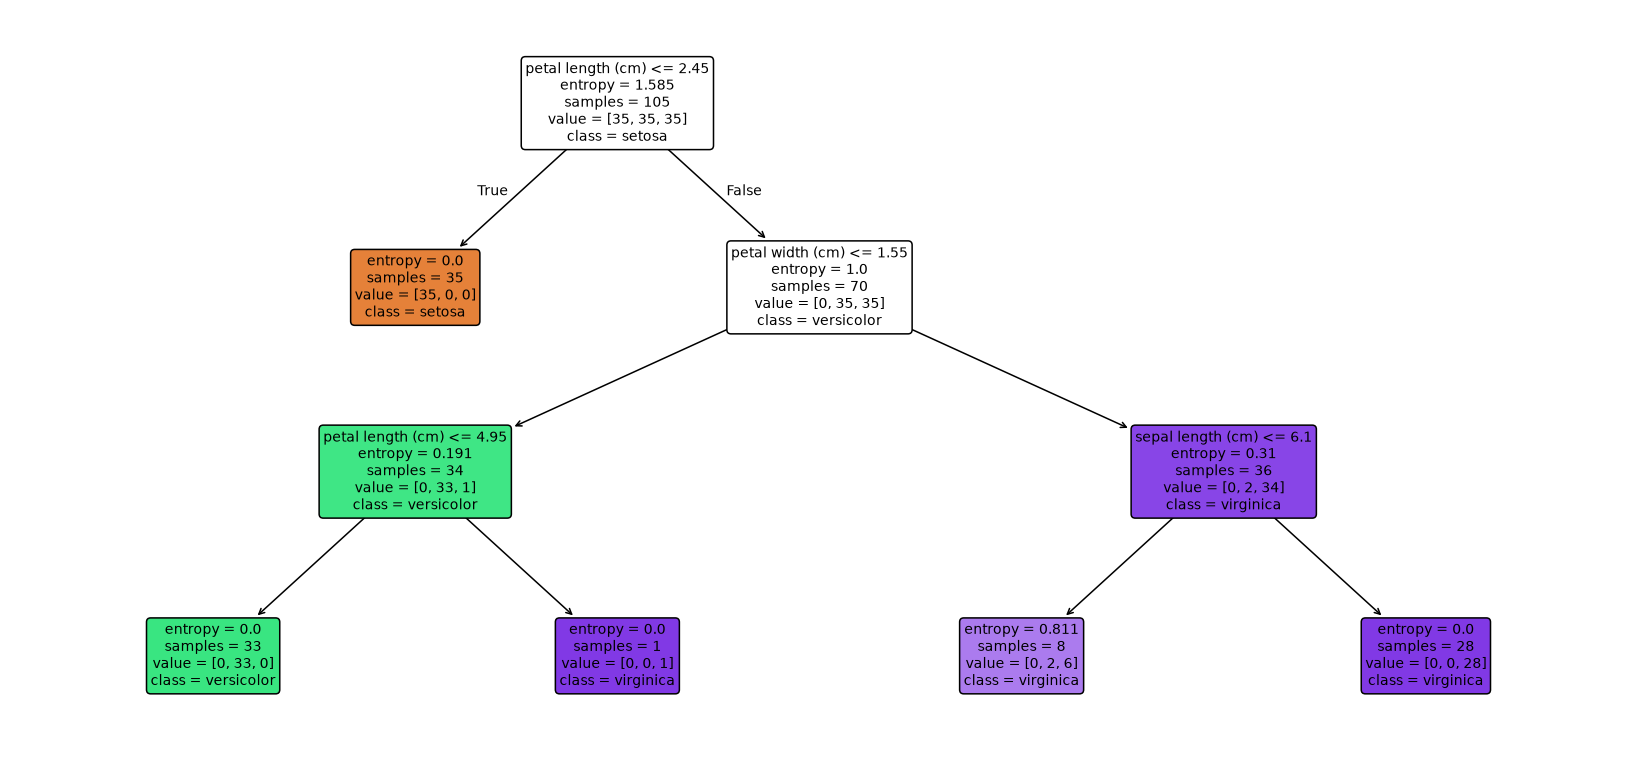

In [5]:
iris = load_iris(as_frame=True)
X, y = iris.data, iris.target
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=RS, stratify=y)

stablo = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=RS).fit(Xtr, ytr)
print(f"Tacnost: trening {stablo.score(Xtr, ytr):.4f}, test {stablo.score(Xte, yte):.4f}\n")

fig, ax = plt.subplots(figsize=(15, 7))
plot_tree(stablo, feature_names=X.columns, class_names=iris.target_names,
          filled=True, rounded=True, fontsize=9, ax=ax)
plt.tight_layout(); plt.show()

In [6]:
# isto stablo kao tekstualna if-then pravila
print(export_text(stablo, feature_names=list(X.columns)))

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.55
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.55
|   |   |--- sepal length (cm) <= 6.10
|   |   |   |--- class: 2
|   |   |--- sepal length (cm) >  6.10
|   |   |   |--- class: 2



## Overfitting kod stabala

Znak preprilagođavanja je **preveliko, duboko stablo** sa mnogo čvorova i grananja.

Cilj je **malo, kompaktno** stablo — po principu *Occam's razor*: jednostavnije je bolje.

### Kako se izbegava

| tehnika | opis |
|---|---|
| **Post-pruning** | stablo se prvo potpuno izgradi, pa se uklanjaju grane koje ne doprinose tačnosti |
| **Validacija** | ako uklanjanje grane ne smanjuje tačnost (npr. u k-fold CV), grana je nepotrebna |
| **Early stopping** | prekid grananja kada novi split ne donosi statistički značajno poboljšanje |

Ključni hiperparametri u `scikit-learn`: `max_depth`, `min_samples_leaf`, `min_samples_split`,
`ccp_alpha` (za post-pruning).

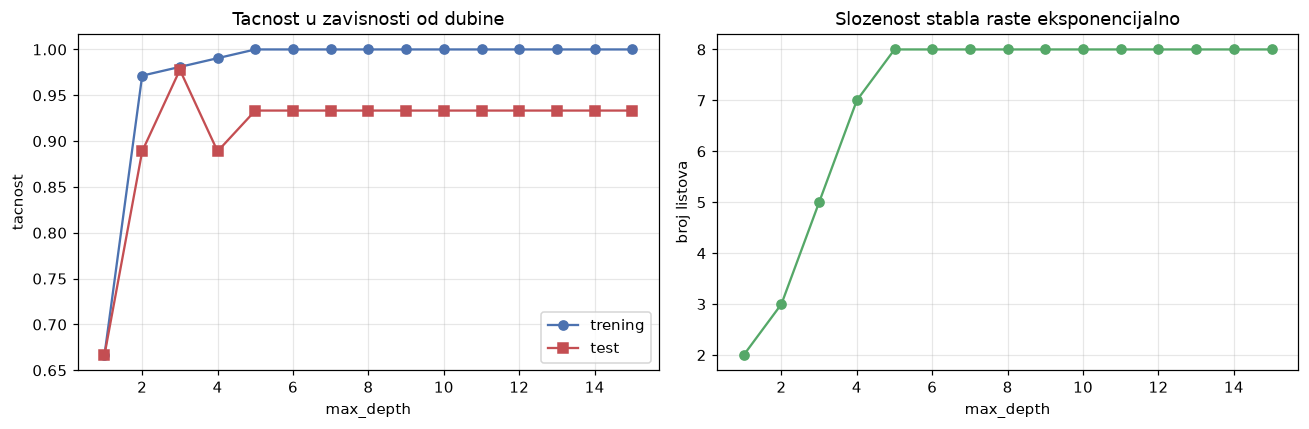

In [7]:
dubine = range(1, 16)
tr, te, listovi = [], [], []
for d in dubine:
    m = DecisionTreeClassifier(max_depth=d, random_state=RS).fit(Xtr, ytr)
    tr.append(m.score(Xtr, ytr)); te.append(m.score(Xte, yte))
    listovi.append(m.get_n_leaves())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(dubine), tr, "o-", label="trening", color="#4C72B0")
ax[0].plot(list(dubine), te, "s-", label="test", color="#C44E52")
ax[0].set_xlabel("max_depth"); ax[0].set_ylabel("tacnost")
ax[0].set_title("Tacnost u zavisnosti od dubine"); ax[0].legend()
ax[1].plot(list(dubine), listovi, "o-", color="#55A868")
ax[1].set_xlabel("max_depth"); ax[1].set_ylabel("broj listova")
ax[1].set_title("Slozenost stabla raste eksponencijalno")
plt.tight_layout(); plt.show()

In [8]:
# post-pruning preko ccp_alpha (cost complexity pruning)
put = DecisionTreeClassifier(random_state=RS).cost_complexity_pruning_path(Xtr, ytr)
alfe = put.ccp_alphas[:-1]

rez = []
for a in alfe:
    m = DecisionTreeClassifier(random_state=RS, ccp_alpha=a).fit(Xtr, ytr)
    rez.append({"alpha": round(a, 5), "listova": m.get_n_leaves(),
                "trening": round(m.score(Xtr, ytr), 4), "test": round(m.score(Xte, yte), 4)})
tab = pd.DataFrame(rez).drop_duplicates("listova")
display(tab)
print("-> Orezivanje smanjuje broj listova, a test tacnost cesto ostaje ista ili raste.")

,alpha,listova,trening,test
0,0.00000,8,1.0000,0.9333
1,0.00899,4,0.9810,0.9333
2,0.01849,3,0.9714,0.8889
3,0.27887,2,0.6667,0.6667


-> Orezivanje smanjuje broj listova, a test tacnost cesto ostaje ista ili raste.


## Stablo odlučivanja za regresiju

Ključna razlika u odnosu na klasifikaciju:

| | klasifikacija | regresija |
|---|---|---|
| predikcija | diskretna klasa | **kontinuirana vrednost** |
| u listu | većinska klasa | **prosečna vrednost** ciljne promenljive u tom regionu |
| kriterijum podele | entropija / Gini | **MSE** ili *variance reduction* |

Cilj je pronaći podelu koja **najviše smanjuje varijansu** ciljne promenljive.

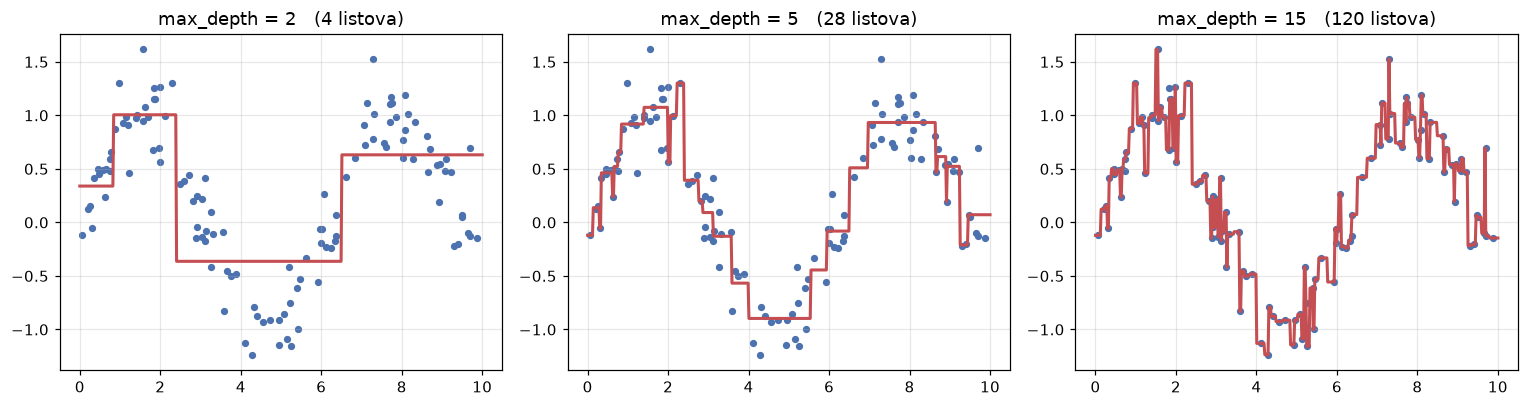

Predikcija je STEPENASTA — u svakom listu je konstanta (prosek tog regiona).


In [9]:
rng = np.random.RandomState(RS)
Xr = np.sort(rng.uniform(0, 10, 120)).reshape(-1, 1)
yr = np.sin(Xr).ravel() + rng.normal(0, 0.25, 120)
xx = np.linspace(0, 10, 500).reshape(-1, 1)

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
for a, d in zip(ax, (2, 5, 15)):
    m = DecisionTreeRegressor(max_depth=d, random_state=RS).fit(Xr, yr)
    a.scatter(Xr, yr, s=14, color="#4C72B0")
    a.plot(xx, m.predict(xx), color="#C44E52", lw=2)
    a.set_title(f"max_depth = {d}   ({m.get_n_leaves()} listova)")
plt.tight_layout(); plt.show()
print("Predikcija je STEPENASTA — u svakom listu je konstanta (prosek tog regiona).")

## Zašto su stabla dobar izbor

1. **Diskretan, jasan izlaz** — pogodno kada treba konkretna odluka, a ne verovatnoća
2. **Rade i sa malo podataka** — upotrebljiv model već sa 10–200 instanci
3. **Otpornost na šum**
4. **Razdvojive klase** — jednostavna pravila često dovoljna
5. **Praktične prednosti** — brzo treniranje, mala memorija, jednostavna implementacija

Iako su konceptualno jednostavna, napredne verzije (**ensemble metode**, predavanje 12)
mogu postići performanse uporedive sa dubokim neuronskim mrežama.